In [1]:
#Phase 1: Data Initialization & Matrix Setup


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split

%matplotlib inline
sns.set_style('whitegrid')

In [3]:
# User-Item Interaction Matrix
np.random.seed(42)
raw_matrix = np.random.choice([0, 1, 2, 3, 4, 5], size=(10, 8), p=[0.3, 0.1, 0.1, 0.2, 0.1, 0.2])

users = [f'User_{i}' for i in range(1, 11)]
items = [f'Item_{j}' for j in range(1, 9)]

df_matrix = pd.DataFrame(raw_matrix, index=users, columns=items)
print("--- User-Item Interaction Matrix ---")
df_matrix

--- User-Item Interaction Matrix ---


,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8
User_1,1,5,4,3,0,0,0,5
User_2,3,4,0,5,5,0,0,0
User_3,1,3,2,0,3,0,0,1
User_4,2,4,0,3,3,0,3,0
User_5,0,5,5,5,1,0,3,2
User_6,0,2,0,5,0,3,1,3
User_7,3,0,5,4,5,5,3,5
User_8,0,0,0,1,1,0,5,1
User_9,0,3,0,5,0,5,4,0
User_10,0,5,4,4,4,0,1,0


In [5]:
# Phase 2: Pattern Learning (Finding Similar Users)


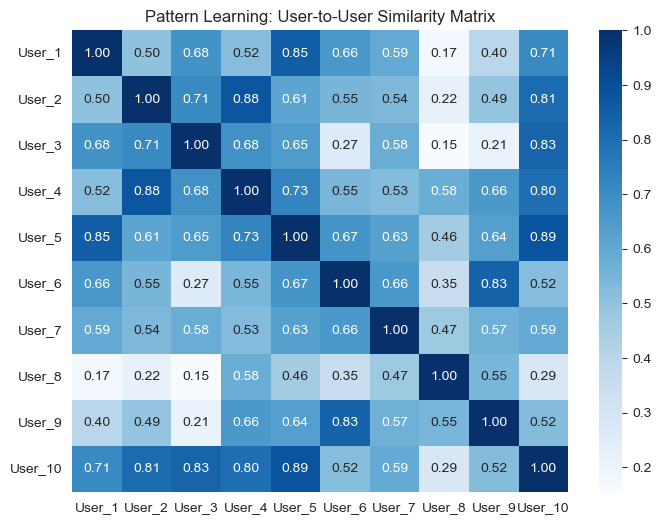

In [6]:
# Compute User Similarity Matrix

# Compute similarity score between all pairs of users
user_similarity = cosine_similarity(df_matrix)
user_sim_df = pd.DataFrame(user_similarity, index=users, columns=users)

# Plot a heatmap to visualize similar user patterns
plt.figure(figsize=(8, 6))
sns.heatmap(user_sim_df, annot=True, cmap='Blues', fmt=".2f")
plt.title('Pattern Learning: User-to-User Similarity Matrix')
plt.show()

In [7]:
# Phase 3: Recommendation Logic (Predicting Ratings)


In [8]:
# The Recommendation Function

def generate_recommendations(user, matrix, similarity_matrix, top_n=2):
    user_idx = matrix.index.get_loc(user)
    sim_scores = similarity_matrix[user_idx]
    
    # Get items the target user hasn't rated yet (value == 0)
    unrated_items = matrix.columns[matrix.loc[user] == 0]
    
    predictions = {}
    for item in unrated_items:
        item_idx = matrix.columns.get_loc(item)
        item_ratings = matrix.iloc[:, item_idx]
        
        # Filter out users who haven't rated the item
        valid_users = item_ratings > 0
        
        if sum(valid_users) == 0:
            continue
            
        # Weighted average rating based on user similarities
        numerator = np.dot(sim_scores[valid_users], item_ratings[valid_users])
        denominator = np.sum(np.abs(sim_scores[valid_users]))
        
        predictions[item] = numerator / denominator if denominator != 0 else 0
        
    # Sort and return top recommendations
    sorted_recs = sorted(predictions.items(), key=lambda x: x[1], reverse=True)
    return sorted_recs[:top_n]

# Test the recommendation logic for User_1
user_to_test = 'User_1'
recs = generate_recommendations(user_to_test, df_matrix, user_similarity, top_n=2)

print(f"Top Recommended Items for {user_to_test}:")
for item, score in recs:
    print(f"➔ {item} (Predicted Interest Score: {score:.2f}/5)")

Top Recommended Items for User_1:
➔ Item_6 (Predicted Interest Score: 4.20/5)
➔ Item_5 (Predicted Interest Score: 3.21/5)


In [10]:
# Phase 4: Evaluation Strategy


In [11]:
# Running Evaluation Metrics
actual_ratings = []
predicted_ratings = []

for user in df_matrix.index:
    user_idx = df_matrix.index.get_loc(user)
    sim_scores = user_similarity[user_idx]
    
    rated_items = df_matrix.columns[df_matrix.loc[user] > 0]
    for item in rated_items[:2]: # Check a small sample of items
        item_idx = df_matrix.columns.get_loc(item)
        item_ratings = df_matrix.iloc[:, item_idx]
        
        other_users = (df_matrix.index != user) & (item_ratings > 0)
        if sum(other_users) > 0:
            pred = np.dot(sim_scores[other_users], item_ratings[other_users]) / np.sum(np.abs(sim_scores[other_users]))
            actual_ratings.append(df_matrix.loc[user, item])
            predicted_ratings.append(pred)

mae_eval = np.mean(np.abs(np.array(actual_ratings) - np.array(predicted_ratings)))
print(f"Recommendation Engine Evaluation MAE: {mae_eval:.2f} stars")

Recommendation Engine Evaluation MAE: 1.17 stars
